# Chapter 14 · Experiment tracking: from a spreadsheet to MLflow

Companion to `notes/14_intro_to_mlflow_experiment_tracking.html` (video 03:26:39 – 03:42:34).

The instructor's argument, reproduced with real code:

1. **Hyperparameter tuning** means training the same model with different parameter values and keeping the best one.
2. Classic ML models are small, so tuning is cheap on a CPU. **Deep learning models have millions of parameters**, so every trial is expensive.
3. Tracking trials **by hand** (the instructor's "Excel sheet") is slow and error-prone.
4. **MLflow** records every run automatically, lets you query and compare runs, and stores the model.

Dataset: red-wine quality (1,599 wines, 11 chemical features → quality score). It's the same data the instructor's MLflow demo uses in the next chapter.
The model is **ElasticNet**, with the two hyperparameters from the video: `alpha` and `l1_ratio`.

In [1]:
import os, time, shutil, itertools, warnings, logging
import certifi
os.environ.setdefault("SSL_CERT_FILE", certifi.where())
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"
warnings.filterwarnings("ignore")
logging.getLogger("mlflow").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# start clean: remove tracking data from previous runs of this notebook
for p in ("mlflow.db", "manual_experiments.csv"):
    if os.path.exists(p): os.remove(p)
shutil.rmtree("mlruns", ignore_errors=True)

BLUE, ORANGE, GRAY, INK2, GRID = "#2a78d6", "#eb6834", "#c3c2b7", "#52514e", "#e7e6e1"
def tidy(ax):
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.grid(axis="y", color=GRID, linewidth=0.8); ax.set_axisbelow(True)

## 1 · The data

In [2]:
URL = "https://raw.githubusercontent.com/mlflow/mlflow/master/tests/datasets/winequality-red.csv"
data = pd.read_csv(URL, sep=";")
print(data.shape)
train, test = train_test_split(data, test_size=0.25, random_state=42)
X_train, y_train = train.drop(columns="quality"), train["quality"]
X_test, y_test = test.drop(columns="quality"), test["quality"]
data.head(3)

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5


In [3]:
def evaluate(model):
    pred = model.predict(X_test)
    return {"rmse": float(np.sqrt(mean_squared_error(y_test, pred))),
            "mae": float(mean_absolute_error(y_test, pred)),
            "r2": float(r2_score(y_test, pred))}

> **Note on metrics.** The video talks about "accuracy" for ElasticNet, but ElasticNet is a **regression** model: it predicts a number (the quality score).
> The right metrics are **RMSE / MAE** (lower is better) and **R²** (higher is better). Those are what the instructor's own demo code logs.

## 2 · Why tuning is cheap for ML but expensive for deep learning  (video 03:29)

Linear regression `y = m·x + c` learns **2** numbers. The instructor's small drawn network (3 inputs → 2 → 2 → 1 output) has 12 weights plus 5 biases.
Real deep networks have **millions**, and each tuning trial means training all of them again.

In [4]:
def mlp_params(sizes):
    """weights + biases of a fully connected net, e.g. [3, 2, 2, 1]"""
    return sum(a * b + b for a, b in zip(sizes[:-1], sizes[1:]))

models = {
    "linear regression (m, c)": 2,
    "instructor's net 3-2-2-1": mlp_params([3, 2, 2, 1]),
    "ElasticNet on wine (11 coefs + intercept)": 12,
    "100-layer MLP, width 512": mlp_params([512] * 101 + [1]),
    "ResNet-50 (published figure)": 25_600_000,
    "BERT-base (published figure)": 110_000_000,
}
for k, v in models.items():
    print(f"{k:45s} {v:>15,}")

linear regression (m, c)                                    2
instructor's net 3-2-2-1                                   17
ElasticNet on wine (11 coefs + intercept)                  12
100-layer MLP, width 512                           26,266,113
ResNet-50 (published figure)                       25,600,000
BERT-base (published figure)                      110,000,000


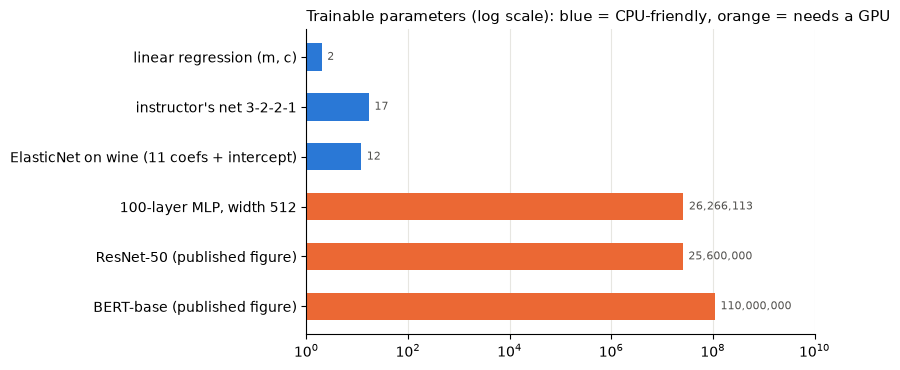

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
names, vals = list(models)[::-1], list(models.values())[::-1]
colors = [ORANGE if v > 1e6 else BLUE for v in vals]
bars = ax.barh(names, vals, color=colors, height=0.55)
ax.set_xscale("log")
ax.bar_label(bars, labels=[f"{v:,}" for v in vals], padding=4, fontsize=8, color=INK2)
ax.set_title("Trainable parameters (log scale): blue = CPU-friendly, orange = needs a GPU", loc="left", fontsize=10.5)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.grid(axis="x", color=GRID, linewidth=0.8); ax.set_axisbelow(True)
ax.set_xlim(1, 1e10)
plt.tight_layout(); plt.show()

In [6]:
# how long does one ElasticNet trial take on a laptop CPU?
t0 = time.perf_counter()
for _ in range(20):
    ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=42).fit(X_train, y_train)
print(f"one ElasticNet fit ≈ {(time.perf_counter() - t0) / 20 * 1000:.1f} ms on CPU")
print("…versus the instructor's example of 1–2 hours per ResNet-50 training run on Colab.")

one ElasticNet fit ≈ 1.4 ms on CPU
…versus the instructor's example of 1–2 hours per ResNet-50 training run on Colab.


## 3 · The instructor's three experiments, tracked by hand  (video 03:34 – 03:38)

A data scientist picks candidate values from experience:
`l1_ratio ∈ {0.5, 0.3, 0.4}` and `alpha ∈ {0.1, 0.9, 0.2}`. In the video each experiment takes one value from each list, in order.
The results go into a spreadsheet, and the best row is picked by eye.

In [7]:
L1_RATIOS = [0.5, 0.3, 0.4]
ALPHAS = [0.1, 0.9, 0.2]

sheet = []                                             # ← the "Excel sheet"
for i, (l1, a) in enumerate(zip(L1_RATIOS, ALPHAS), start=1):
    model = ElasticNet(alpha=a, l1_ratio=l1, random_state=42).fit(X_train, y_train)
    sheet.append({"experiment": i, "l1_ratio": l1, "alpha": a, **evaluate(model)})

manual = pd.DataFrame(sheet)
manual.to_csv("manual_experiments.csv", index=False)  # someone has to save, share and update this file
manual.round(4)

,experiment,l1_ratio,alpha,rmse,mae,r2
0,1,0.5,0.1,0.6916,0.5514,0.2267
1,2,0.3,0.9,0.7560,0.6168,0.0761
2,3,0.4,0.2,0.6985,0.5594,0.2112


In [8]:
best = manual.sort_values("rmse").iloc[0]
print(f"best by hand: experiment {int(best.experiment)} (l1_ratio={best.l1_ratio}, alpha={best.alpha}), RMSE={best.rmse:.4f}")

best by hand: experiment 1 (l1_ratio=0.5, alpha=0.1), RMSE=0.6916


**What goes wrong with the spreadsheet approach**
* Every value is typed or copied by hand, so rows get mixed up easily.
* Nothing links a row to the **code version**, the **data**, or the **saved model file**.
* The three pairs above are only 3 of the **9** possible combinations. A full search grows fast (3 × 3 = 9, and 10 values × 10 values = 100 runs).
* With deep learning, each row can cost hours of GPU time, so losing a result is expensive.

## 4 · The same idea with MLflow  (video 03:39)

A few MLflow calls inside the training loop record **parameters, metrics and the model** for every run.
Here the tracking data goes to a local SQLite file (`mlflow.db`); in Chapter 15 it goes to a remote server (DagsHub).

In [9]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite:///mlflow.db")
exp = mlflow.set_experiment("elasticnet-wine-quality")
print("MLflow", mlflow.__version__, "| experiment id:", exp.experiment_id)

2026/09/16 20:32:31 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/16 20:32:31 INFO mlflow.store.db.utils: Updating database tables


2026/09/16 20:32:31 INFO mlflow.tracking.fluent: Experiment with name 'elasticnet-wine-quality' does not exist. Creating a new experiment.


MLflow 3.16.1 | experiment id: 1


In [10]:
grid = list(itertools.product(L1_RATIOS, ALPHAS))     # all 9 combinations this time
print(len(grid), "runs:", grid)

for l1, a in grid:
    with mlflow.start_run(run_name=f"l1={l1}_alpha={a}"):
        model = ElasticNet(alpha=a, l1_ratio=l1, random_state=42).fit(X_train, y_train)
        metrics = evaluate(model)
        mlflow.log_params({"alpha": a, "l1_ratio": l1})
        mlflow.log_metrics(metrics)
        mlflow.set_tag("stage", "hyperparameter-search")
        mlflow.sklearn.log_model(model, name="model", input_example=X_train.head(2))
print("done")

9 runs: [(0.5, 0.1), (0.5, 0.9), (0.5, 0.2), (0.3, 0.1), (0.3, 0.9), (0.3, 0.2), (0.4, 0.1), (0.4, 0.9), (0.4, 0.2)]


done


### 4.1 · Query the runs instead of reading a spreadsheet

In [11]:
runs = mlflow.search_runs(experiment_names=["elasticnet-wine-quality"], order_by=["metrics.rmse ASC"])
table = runs[["run_id", "params.l1_ratio", "params.alpha", "metrics.rmse", "metrics.mae", "metrics.r2"]].copy()
table["run_id"] = table["run_id"].str[:8]
table.round(4)

,run_id,params.l1_ratio,params.alpha,metrics.rmse,metrics.mae,metrics.r2
0,8e4a2655,0.3,0.1,0.6855,0.5459,0.2404
1,06412087,0.4,0.1,0.6905,0.5499,0.2291
2,c42eb4d0,0.5,0.1,0.6916,0.5514,0.2267
3,0041ba2d,0.3,0.2,0.6953,0.5561,0.2184
4,3802002a,0.4,0.2,0.6985,0.5594,0.2112
5,32393977,0.5,0.2,0.7023,0.5632,0.2026
6,bb7c6efc,0.3,0.9,0.7560,0.6168,0.0761
7,d701c690,0.4,0.9,0.7784,0.6375,0.0205
8,96f7cad0,0.5,0.9,0.7845,0.6434,0.0051


In [12]:
best_run = runs.iloc[0]
print("best run:", best_run["tags.mlflow.runName"], "| RMSE", round(best_run["metrics.rmse"], 4))

# reload the exact model that run logged, and use it
best_model = mlflow.sklearn.load_model(f"runs:/{best_run.run_id}/model")
sample = X_test.head(3)
pd.DataFrame({"predicted": best_model.predict(sample).round(2), "actual": y_test.head(3).values})

best run: l1=0.3_alpha=0.1 | RMSE 0.6855


,predicted,actual
0,5.34,6
1,5.14,5
2,5.63,6


### 4.2 · Parallel coordinates: the chart the instructor points at on the MLflow site  (video 03:40)

Each line is one run. It passes through its `alpha` and `l1_ratio` values and ends at its RMSE, so you can see which parameter values lead to low error.
MLflow's UI draws this under **Compare runs → Parallel Coordinates Plot**. Here it's drawn with matplotlib from `search_runs`:

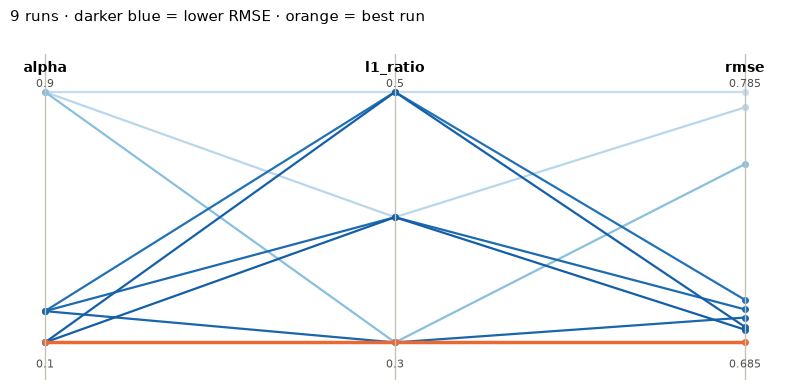

In [13]:
df = runs[["params.alpha", "params.l1_ratio", "metrics.rmse"]].astype(float)
df.columns = ["alpha", "l1_ratio", "rmse"]
axes_cols = ["alpha", "l1_ratio", "rmse"]
norm = (df[axes_cols] - df[axes_cols].min()) / (df[axes_cols].max() - df[axes_cols].min())

fig, ax = plt.subplots(figsize=(8, 4))
cmap = plt.get_cmap("Blues_r")
order = df["rmse"].sort_values(ascending=False).index          # draw the best last (on top)
for idx in order:
    r = (df.loc[idx, "rmse"] - df.rmse.min()) / (df.rmse.max() - df.rmse.min())
    best = idx == df["rmse"].idxmin()
    ax.plot(range(3), norm.loc[idx], color=ORANGE if best else cmap(0.15 + 0.6 * r),
            linewidth=2.5 if best else 1.6, marker="o", markersize=4)
for i, c in enumerate(axes_cols):
    ax.axvline(i, color=GRAY, linewidth=1)
    ax.text(i, 1.08, c, ha="center", fontsize=10, fontweight="bold")
    ax.text(i, -0.1, f"{df[c].min():.3g}", ha="center", fontsize=8, color=INK2)
    ax.text(i, 1.02, f"{df[c].max():.3g}", ha="center", fontsize=8, color=INK2)
ax.set_xticks([]); ax.set_yticks([]); ax.set_ylim(-0.15, 1.15)
for s in ax.spines.values(): s.set_visible(False)
ax.set_title("9 runs · darker blue = lower RMSE · orange = best run", loc="left", fontsize=10.5, pad=24)
plt.tight_layout(); plt.show()

In [14]:
pivot = runs.pivot_table(index="params.alpha", columns="params.l1_ratio", values="metrics.rmse").round(4)
pivot.index.name, pivot.columns.name = "alpha ↓", "l1_ratio →"
print("RMSE for every combination (lower is better):")
pivot

RMSE for every combination (lower is better):


l1_ratio →,0.3,0.4,0.5
alpha ↓,,,
0.1,0.6855,0.6905,0.6916
0.2,0.6953,0.6985,0.7023
0.9,0.7560,0.7784,0.7845


**Reading the result:** smaller `alpha` (less regularisation) gives lower error on this dataset, and `l1_ratio` matters much less.
The spreadsheet's 3 hand-picked pairs happened to include the best `alpha`, but only the full grid shows the pattern.

### 4.3 · Even less code: autologging
`mlflow.sklearn.autolog()` records parameters, training metrics and the model with **no** explicit `log_*` calls.

In [15]:
mlflow.sklearn.autolog(log_models=False, silent=True)
with mlflow.start_run(run_name="autolog-demo") as run:
    ElasticNet(alpha=0.05, l1_ratio=0.3, random_state=42).fit(X_train, y_train)
mlflow.sklearn.autolog(disable=True)

auto = mlflow.get_run(run.info.run_id)
print("params logged automatically:", len(auto.data.params))
print({k: auto.data.params[k] for k in ("alpha", "l1_ratio", "max_iter")})
print("metrics:", {k: round(v, 4) for k, v in auto.data.metrics.items()})

params logged automatically: 11
{'alpha': '0.05', 'l1_ratio': '0.3', 'max_iter': '1000'}
metrics: {'training_mean_squared_error': 0.4629, 'training_mean_absolute_error': 0.5237, 'training_r2_score': 0.3013, 'training_root_mean_squared_error': 0.6804, 'training_score': 0.3013}


## 5 · Open the MLflow UI

From this folder, in a terminal:

```bash
source ../.venv/bin/activate
mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000
```

Then open <http://127.0.0.1:5000>. Choose the **elasticnet-wine-quality** experiment, select the runs, and click **Compare** to see the parallel-coordinates, scatter and contour plots.

## Summary

| | Spreadsheet (manual) | MLflow |
|---|---|---|
| recording | type values by hand | `log_params` / `log_metrics` / `autolog()` |
| finding the best | sort by eye | `search_runs(order_by=…)` or the UI |
| model file | saved separately (if at all) | logged with the run → `runs:/<id>/model` |
| comparing | manual charts | built-in parallel coordinates, scatter, contour |
| sharing | email the file | shared tracking server (Chapter 15: DagsHub) |